In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from transformers import AutoTokenizer
import tiktoken


In [2]:
# GPT tokenizer
gpt_enc = tiktoken.get_encoding("cl100k_base")

# MuRIL tokenizer
muril_tokenizer = AutoTokenizer.from_pretrained("google/muril-base-cased")

#mBERT tokenizer
mBERT_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")


In [3]:

from datasets import load_dataset

dataset = load_dataset("ai4bharat/Bhasha-Abhijnaanam")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 1
    })
})


In [4]:
print(dataset["train"].features)


{'data': List({'unique_identifier': Value('string'), 'native sentence': Value('string'), 'romanized sentence': Value('string'), 'language': Value('string'), 'script': Value('string'), 'source': Value('string')})}


In [5]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 1
    })
})


In [6]:
data = dataset["train"][0]["data"]

print(type(data))
print(len(data))


<class 'list'>
88014


In [7]:
bn_data = [x for x in data if x["language"] == "Bangla"]
hi_data = [x for x in data if x["language"] == "Hindi"]

print("Bengali:", len(bn_data))
print("Hindi:", len(hi_data))


Bengali: 5612
Hindi: 5628


In [8]:
import random

bn_sample = random.sample(bn_data, 400)
hi_sample = random.sample(hi_data, 400)

In [9]:
# Remove entries where native OR roman is empty
clean_bn_data = [
    x for x in bn_sample
    if x["native sentence"].strip() != "" 
    and x["romanized sentence"].strip() != ""
]

print("Total valid Bengali pairs:", len(clean_bn_data))

Total valid Bengali pairs: 327


In [10]:
# Remove entries where native OR roman is empty
clean_hi_data = [
    x for x in hi_sample
    if x["native sentence"].strip() != "" 
    and x["romanized sentence"].strip() != ""
]

print("Total valid Hindi pairs:", len(clean_bn_data))


Total valid Hindi pairs: 327


In [11]:
random.seed(42)
bn_samples = random.sample(clean_bn_data, 200)
bn_samples[0]

{'unique_identifier': 'bn_2677',
 'native sentence': 'কনেকে বরের হাতে তুলে দেন কনেপক্ষ এবং বরপক্ষ, কনেকে নিয়ে বেরিয়ে আসেন অনুষ্ঠানস্থল থেকে স্বীয় বাড়ি অভিমুখে।',
 'romanized sentence': 'koneke borer haate tule den konepokkho ebong borpokkho, koneke niye beriye asen ghotonasthol theke swiyo bari abhimukhe.',
 'language': 'Bangla',
 'script': 'Bengali',
 'source': 'Dakshina'}

In [12]:
random.seed(42)
hi_samples = random.sample(clean_hi_data, 200)
hi_samples[0]

{'unique_identifier': 'hi_2070',
 'native sentence': 'गाँजे के पौधे से एक प्रकार का लासा भी निकलता है।',
 'romanized sentence': 'Gauge ke paudhe se eak pakar ka laasa bhi nikalta hai.',
 'language': 'Hindi',
 'script': 'Devanagari',
 'source': 'Dakshina'}

#### GPT Tokenizer for Bengali

In [13]:
import numpy as np
import matplotlib.pyplot as plt

native_counts_gpt_bn = []
roman_counts_gpt_bn = []
ssr_values_gpt = []

for i, x in enumerate(bn_samples, 1):
    native = x["native sentence"].strip()
    roman = x["romanized sentence"].strip()

    native_tokens = len(gpt_enc.encode(native))
    roman_tokens = len(gpt_enc.encode(roman))
    

    native_counts_gpt_bn.append(native_tokens)
    roman_counts_gpt_bn.append(roman_tokens)
    ssr_values_gpt.append(roman_tokens / native_tokens)

mean_ssr_gpt_bn = np.mean(ssr_values_gpt)
print("Mean SSR:", mean_ssr_gpt_bn)

Mean SSR: 0.3174031733475991


#### MuRIL Tokenizer for Bengali

In [14]:
native_counts_muril_bn = []
roman_counts_muril_bn = []
ssr_values_muril = []
valid_indices = []

for i, x in enumerate(bn_samples, 1):
    native = x["native sentence"].strip()
    roman = x["romanized sentence"].strip()

    native_tokens = len(muril_tokenizer.tokenize(native))
    roman_tokens = len(muril_tokenizer.tokenize(roman))

    native_counts_muril_bn.append(native_tokens)
    roman_counts_muril_bn.append(roman_tokens)
    ssr_values_muril.append(roman_tokens / native_tokens)

mean_ssr_muril_bn = np.mean(ssr_values_muril)
print("Mean SSR:", mean_ssr_muril_bn)

Mean SSR: 1.7182028104251015


#### GPT Tokenizer for Hindi

In [15]:
native_counts_gpt_hi = []
roman_counts_gpt_hi = []
ssr_values_gpt_hi = []

for i, x in enumerate(hi_samples, 1):
    native = x["native sentence"].strip()
    roman = x["romanized sentence"].strip()

    native_tokens = len(gpt_enc.encode(native))
    roman_tokens = len(gpt_enc.encode(roman))

    native_counts_gpt_hi.append(native_tokens)
    roman_counts_gpt_hi.append(roman_tokens)
    ssr_values_gpt_hi.append(roman_tokens / native_tokens)

mean_ssr_gpt_hi = np.mean(ssr_values_gpt_hi)
print("Mean SSR:", mean_ssr_gpt_hi)


Mean SSR: 0.40645007801577515


#### MuRIL Tokenizer for Hindi

In [16]:
native_counts_muril_hi = []
roman_counts_muril_hi = []
ssr_values_muril_hi = []
valid_indices = []

for i, x in enumerate(hi_samples, 1):
    native = x["native sentence"].strip()
    roman = x["romanized sentence"].strip()

    native_tokens = len(muril_tokenizer.tokenize(native))
    roman_tokens = len(muril_tokenizer.tokenize(roman))

    native_counts_muril_hi.append(native_tokens)
    roman_counts_muril_hi.append(roman_tokens)
    ssr_values_muril_hi.append(roman_tokens / native_tokens)

mean_ssr_muril_hi = np.mean(ssr_values_muril_hi)
print("Mean SSR:", mean_ssr_muril_hi)


Mean SSR: 1.2553759426733386


#### mBERT Bengali Tokenizer

In [17]:
native_counts_mbert_bn = []
roman_counts_mbert_bn = []
ssr_values_mbert_bn = []

for i, x in enumerate(bn_samples, 1):
    native = x["native sentence"].strip()
    roman = x["romanized sentence"].strip()

    native_tokens = len(mBERT_tokenizer.tokenize(native))
    roman_tokens = len(mBERT_tokenizer.tokenize(roman))

    native_counts_mbert_bn.append(native_tokens)
    roman_counts_mbert_bn.append(roman_tokens)
    ssr_values_mbert_bn.append(roman_tokens / native_tokens)

mean_ssr_mbert_bn = np.mean(ssr_values_mbert_bn)
print("Mean SSR:", mean_ssr_mbert_bn)


Mean SSR: 0.8898919913892586


#### mBERT Hindi Tokenizer

In [18]:
native_counts_mbert_hi = []
roman_counts_mbert_hi = []
ssr_values_mbert_hi = []

for i, x in enumerate(hi_samples, 1):
    native = x["native sentence"].strip()
    roman = x["romanized sentence"].strip()

    native_tokens = len(mBERT_tokenizer.tokenize(native))
    roman_tokens = len(mBERT_tokenizer.tokenize(roman))

    native_counts_mbert_hi.append(native_tokens)
    roman_counts_mbert_hi.append(roman_tokens)
    ssr_values_mbert_hi.append(roman_tokens / native_tokens)

mean_ssr_mbert_hi = np.mean(ssr_values_mbert_hi)
print("Mean SSR:", mean_ssr_mbert_hi)

Mean SSR: 1.0154141384860886


#### NSL for GPT Bengali 

In [19]:

# Native Script

gpt_bn_native_avg = np.mean(native_counts_gpt_bn)
muril_bn_native_avg = np.mean(native_counts_muril_bn)
mbert_bn_native_avg = np.mean(native_counts_mbert_bn)

gpt_bn_nsl_native_vs_muril = gpt_bn_native_avg / muril_bn_native_avg
gpt_bn_nsl_native_vs_mbert = gpt_bn_native_avg / mbert_bn_native_avg

print("Native Bengali NSL (GPT vs MuRIL):", gpt_bn_nsl_native_vs_muril)
print("Native Bengali NSL (GPT vs mBERT):", gpt_bn_nsl_native_vs_mbert)


# Roman Script

gpt_bn_roman_avg = np.mean(roman_counts_gpt_bn)
muril_bn_roman_avg = np.mean(roman_counts_muril_bn)
mbert_bn_roman_avg = np.mean(roman_counts_mbert_bn)

gpt_bn_nsl_roman_vs_muril = gpt_bn_roman_avg / muril_bn_roman_avg
gpt_bn_nsl_roman_vs_mbert = gpt_bn_roman_avg / mbert_bn_roman_avg

print("Roman Bengali NSL (GPT vs MuRIL):", gpt_bn_nsl_roman_vs_muril)
print("Roman Bengali NSL (GPT vs mBERT):", gpt_bn_nsl_roman_vs_mbert)

Native Bengali NSL (GPT vs MuRIL): 5.908845738942826
Native Bengali NSL (GPT vs mBERT): 2.8704310231887855
Roman Bengali NSL (GPT vs MuRIL): 1.1115229653505239
Roman Bengali NSL (GPT vs mBERT): 1.0480170186901687


#### NSL for MuRIL Bengali

In [20]:
# Native Script

muril_bn_nsl_native_vs_gpt = muril_bn_native_avg / gpt_bn_native_avg
muril_bn_nsl_native_vs_mbert = muril_bn_native_avg / mbert_bn_native_avg

print("Native Bengali NSL (MuRIL vs GPT):", muril_bn_nsl_native_vs_gpt)
print("Native Bengali NSL (MuRIL vs mBERT):", muril_bn_nsl_native_vs_mbert)


# Roman Script


muril_bn_nsl_roman_vs_gpt = muril_bn_roman_avg / gpt_bn_roman_avg
muril_bn_nsl_roman_vs_mbert = muril_bn_roman_avg / mbert_bn_roman_avg

print("Roman Bengali NSL (MuRIL vs MuRIL):", muril_bn_nsl_roman_vs_gpt)
print("Roman Bengali NSL (MuRIL vs mBERT):", muril_bn_nsl_roman_vs_mbert)

Native Bengali NSL (MuRIL vs GPT): 0.16923779096303057
Native Bengali NSL (MuRIL vs mBERT): 0.4857854054762217
Roman Bengali NSL (MuRIL vs MuRIL): 0.8996665216760911
Roman Bengali NSL (MuRIL vs mBERT): 0.9428658258623309


#### NSL for MBERT Bengali

In [21]:
# Native Script

mbert_bn_nsl_native_vs_gpt = mbert_bn_native_avg / gpt_bn_native_avg
mbert_bn_nsl_native_vs_muril = mbert_bn_native_avg / muril_bn_native_avg

print("Native Bengali NSL (mBERT vs GPT):", mbert_bn_nsl_native_vs_gpt)
print("Native Bengali NSL (mBERT vs MuRIL):", mbert_bn_nsl_native_vs_muril)


# Roman Script


mbert_bn_nsl_roman_vs_gpt = mbert_bn_roman_avg / gpt_bn_roman_avg
mbert_bn_nsl_roman_vs_muril = mbert_bn_roman_avg / muril_bn_roman_avg

print("Roman Bengali NSL (mBERT vs GPT):", muril_bn_nsl_roman_vs_gpt)
print("Roman Bengali NSL (mBERT vs MuRIL):", muril_bn_nsl_roman_vs_mbert)

Native Bengali NSL (mBERT vs GPT): 0.34837973528069377
Native Bengali NSL (mBERT vs MuRIL): 2.0585221143473573
Roman Bengali NSL (mBERT vs GPT): 0.8996665216760911
Roman Bengali NSL (mBERT vs MuRIL): 0.9428658258623309


#### Bengali Heat Maps

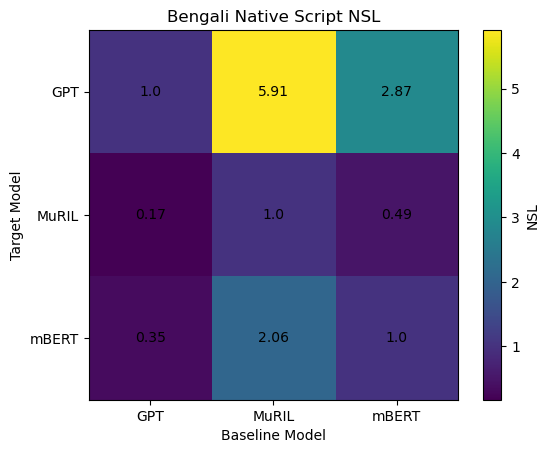

In [22]:

models = ["GPT", "MuRIL", "mBERT"]

bn_native_matrix = np.array([
    [1.0, gpt_bn_nsl_native_vs_muril, gpt_bn_nsl_native_vs_mbert],
    [muril_bn_nsl_native_vs_gpt, 1.0, muril_bn_nsl_native_vs_mbert],
    [mbert_bn_nsl_native_vs_gpt, mbert_bn_nsl_native_vs_muril, 1.0]
])

plt.figure()
plt.imshow(bn_native_matrix)

plt.xticks(range(len(models)), models)
plt.yticks(range(len(models)), models)

plt.colorbar(label="NSL")

for i in range(len(models)):
    for j in range(len(models)):
        plt.text(j, i, round(bn_native_matrix[i, j], 2),
                 ha="center", va="center")

plt.title("Bengali Native Script NSL")
plt.xlabel("Baseline Model")
plt.ylabel("Target Model")

plt.show()

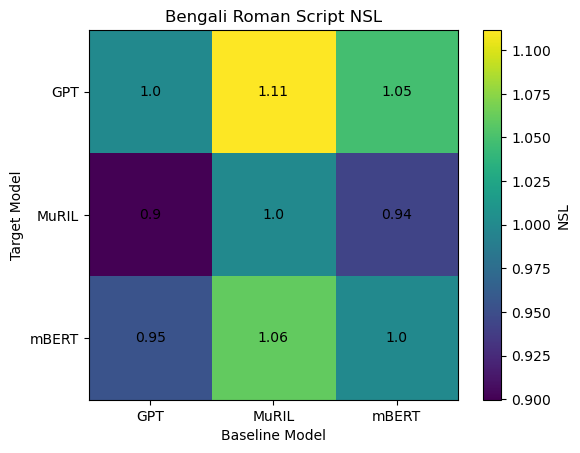

In [23]:
bn_roman_matrix = np.array([
    [1.0, gpt_bn_nsl_roman_vs_muril, gpt_bn_nsl_roman_vs_mbert],
    [muril_bn_nsl_roman_vs_gpt, 1.0, muril_bn_nsl_roman_vs_mbert],
    [mbert_bn_nsl_roman_vs_gpt, mbert_bn_nsl_roman_vs_muril, 1.0]
])

plt.figure()
plt.imshow(bn_roman_matrix)

plt.xticks(range(len(models)), models)
plt.yticks(range(len(models)), models)

plt.colorbar(label="NSL")

for i in range(len(models)):
    for j in range(len(models)):
        plt.text(j, i, round(bn_roman_matrix[i, j], 2),
                 ha="center", va="center")

plt.title("Bengali Roman Script NSL")
plt.xlabel("Baseline Model")
plt.ylabel("Target Model")

plt.show()

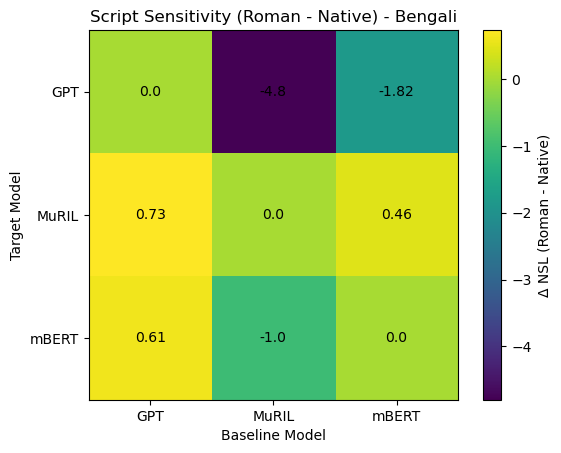

In [24]:
bn_difference_matrix = bn_roman_matrix - bn_native_matrix

plt.figure()
plt.imshow(bn_difference_matrix)

plt.xticks(range(len(models)), models)
plt.yticks(range(len(models)), models)

plt.colorbar(label="Δ NSL (Roman - Native)")

for i in range(len(models)):
    for j in range(len(models)):
        plt.text(j, i, round(bn_difference_matrix[i, j], 2),
                 ha="center", va="center")

plt.title("Script Sensitivity (Roman - Native) - Bengali")
plt.xlabel("Baseline Model")
plt.ylabel("Target Model")

plt.show()

#### NSL for GPT Hindi

In [25]:
# Native Script

gpt_hi_native_avg = np.mean(native_counts_gpt_hi)
muril_hi_native_avg = np.mean(native_counts_muril_hi)
mbert_hi_native_avg = np.mean(native_counts_mbert_hi)

gpt_hi_nsl_native_vs_muril = gpt_hi_native_avg / muril_hi_native_avg
gpt_hi_nsl_native_vs_mbert = gpt_hi_native_avg / mbert_hi_native_avg

print("Native Hindi NSL (GPT vs MuRIL):", gpt_hi_nsl_native_vs_muril)
print("Native Hindi NSL (GPT vs mBERT):", gpt_hi_nsl_native_vs_mbert)


# Roman Script

gpt_hi_roman_avg = np.mean(roman_counts_gpt_hi)
muril_hi_roman_avg = np.mean(roman_counts_muril_hi)
mbert_hi_roman_avg = np.mean(roman_counts_mbert_hi)

gpt_hi_nsl_roman_vs_muril = gpt_hi_roman_avg / muril_hi_roman_avg
gpt_hi_nsl_roman_vs_mbert = gpt_hi_roman_avg / mbert_hi_roman_avg

print("Roman Hindi NSL (GPT vs MuRIL):", gpt_hi_nsl_roman_vs_muril)
print("Roman Hindi NSL (GPT vs mBERT):", gpt_hi_nsl_roman_vs_mbert)

Native Hindi NSL (GPT vs MuRIL): 4.135280553420445
Native Hindi NSL (GPT vs mBERT): 2.5723165192445614
Roman Hindi NSL (GPT vs MuRIL): 1.3426399875911277
Roman Hindi NSL (GPT vs mBERT): 1.0485766202301636


#### NSL for MuRIL Hindi

In [26]:
# Native Script


muril_hi_nsl_native_vs_gpt = muril_hi_native_avg / gpt_hi_native_avg
muril_hi_nsl_native_vs_mbert = muril_hi_native_avg / mbert_hi_native_avg

print("Native Hindi NSL (MuRIL vs GPT):", muril_hi_nsl_native_vs_gpt)
print("Native Hindi NSL (MuRIL vs mBERT):", muril_hi_nsl_native_vs_mbert)


# Roman Script


muril_hi_nsl_roman_vs_gpt = muril_hi_roman_avg / gpt_hi_roman_avg
muril_hi_nsl_roman_vs_mbert = muril_hi_roman_avg / mbert_hi_roman_avg

print("Roman Hindi NSL (MuRIL vs GPT):", muril_hi_nsl_roman_vs_gpt)
print("Roman Hindi NSL (MuRIL vs mBERT):", muril_hi_nsl_roman_vs_mbert)

Native Hindi NSL (MuRIL vs GPT): 0.24182156133828997
Native Hindi NSL (MuRIL vs mBERT): 0.6220415969399953
Roman Hindi NSL (MuRIL vs GPT): 0.7448012939001848
Roman Hindi NSL (MuRIL vs mBERT): 0.7809812235009086


#### NSL for mBERT Hindi

In [27]:
# Native Script


mbert_hi_nsl_native_vs_gpt = mbert_hi_native_avg / gpt_hi_native_avg
mbert_hi_nsl_native_vs_muril = mbert_hi_native_avg / muril_hi_native_avg

print("Native Hindi NSL (mBERT vs GPT):", mbert_hi_nsl_native_vs_gpt)
print("Native Hindi NSL (mBERT vs MuRIL):", mbert_hi_nsl_native_vs_muril)


# Roman Script


mbert_hi_nsl_roman_vs_gpt = mbert_hi_roman_avg / gpt_hi_roman_avg
mbert_hi_nsl_roman_vs_muril = mbert_hi_roman_avg / muril_hi_roman_avg

print("Roman Hindi NSL (mBERT vs GPT):", mbert_hi_nsl_roman_vs_gpt)
print("Roman Hindi NSL (mBERT vs MuRIL):", mbert_hi_nsl_roman_vs_muril)

Native Hindi NSL (mBERT vs GPT): 0.3887546468401487
Native Hindi NSL (mBERT vs MuRIL): 1.6076095311299001
Roman Hindi NSL (mBERT vs GPT): 0.953673752310536
Roman Hindi NSL (mBERT vs MuRIL): 1.2804405149682023


#### Hindi Heat Maps

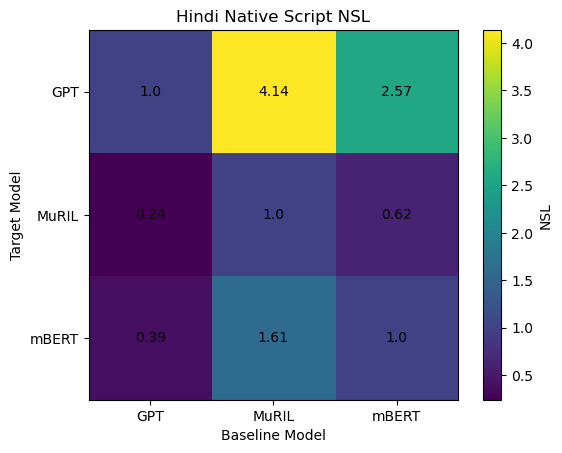

In [28]:

models = ["GPT", "MuRIL", "mBERT"]

hi_native_matrix = np.array([
    [1.0, gpt_hi_nsl_native_vs_muril, gpt_hi_nsl_native_vs_mbert],
    [muril_hi_nsl_native_vs_gpt, 1.0, muril_hi_nsl_native_vs_mbert],
    [mbert_hi_nsl_native_vs_gpt, mbert_hi_nsl_native_vs_muril, 1.0]
])

plt.figure()
plt.imshow(hi_native_matrix)

plt.xticks(range(len(models)), models)
plt.yticks(range(len(models)), models)

plt.colorbar(label="NSL")

for i in range(len(models)):
    for j in range(len(models)):
        plt.text(j, i, round(hi_native_matrix[i, j], 2),
                 ha="center", va="center")

plt.title("Hindi Native Script NSL")
plt.xlabel("Baseline Model")
plt.ylabel("Target Model")

plt.show()

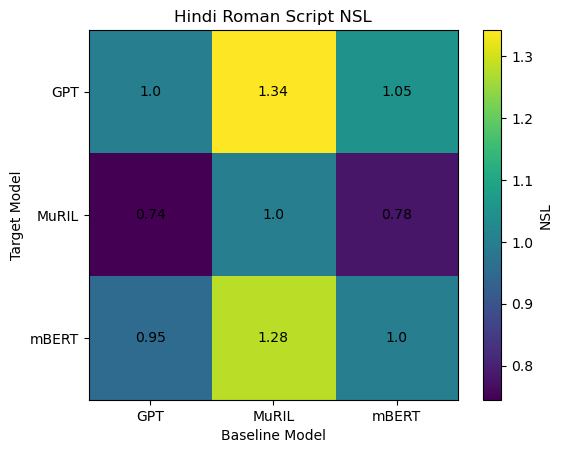

In [29]:
hi_roman_matrix = np.array([
    [1.0, gpt_hi_nsl_roman_vs_muril, gpt_hi_nsl_roman_vs_mbert],
    [muril_hi_nsl_roman_vs_gpt, 1.0, muril_hi_nsl_roman_vs_mbert],
    [mbert_hi_nsl_roman_vs_gpt, mbert_hi_nsl_roman_vs_muril, 1.0]
])

plt.figure()
plt.imshow(hi_roman_matrix)

plt.xticks(range(len(models)), models)
plt.yticks(range(len(models)), models)

plt.colorbar(label="NSL")

for i in range(len(models)):
    for j in range(len(models)):
        plt.text(j, i, round(hi_roman_matrix[i, j], 2),
                 ha="center", va="center")

plt.title("Hindi Roman Script NSL")
plt.xlabel("Baseline Model")
plt.ylabel("Target Model")

plt.show()

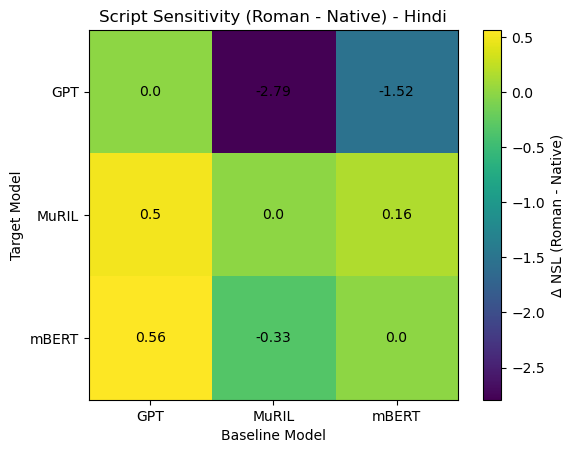

In [30]:
hi_difference_matrix = hi_roman_matrix - hi_native_matrix

plt.figure()
plt.imshow(hi_difference_matrix)

plt.xticks(range(len(models)), models)
plt.yticks(range(len(models)), models)

plt.colorbar(label="Δ NSL (Roman - Native)")

for i in range(len(models)):
    for j in range(len(models)):
        plt.text(j, i, round(hi_difference_matrix[i, j], 2),
                 ha="center", va="center")

plt.title("Script Sensitivity (Roman - Native) - Hindi")
plt.xlabel("Baseline Model")
plt.ylabel("Target Model")

plt.show()

#### Language Comparison

In [31]:
models = ["GPT", "MuRIL", "mBERT"]

bn_ssr = [mean_ssr_gpt_bn, mean_ssr_muril_bn, mean_ssr_mbert_bn]
hi_ssr = [mean_ssr_gpt_hi, mean_ssr_muril_hi, mean_ssr_mbert_hi]

print (bn_ssr)
print (hi_ssr)

[np.float64(0.3174031733475991), np.float64(1.7182028104251015), np.float64(0.8898919913892586)]
[np.float64(0.40645007801577515), np.float64(1.2553759426733386), np.float64(1.0154141384860886)]


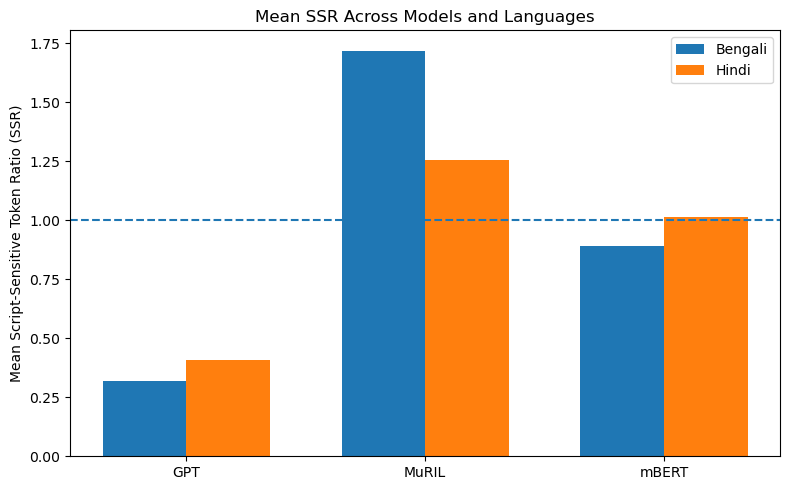

In [32]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, bn_ssr, width, label="Bengali")
plt.bar(x + width/2, hi_ssr, width, label="Hindi")

plt.xticks(x, models)
plt.ylabel("Mean Script-Sensitive Token Ratio (SSR)")
plt.title("Mean SSR Across Models and Languages")
plt.axhline(1, linestyle="--")  # SSR=1 baseline (balanced tokenization)
plt.legend()

plt.tight_layout()
plt.show()